 # Mini notebook — poster-ready interpretability figures

In [9]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore")


In [10]:
BASE_DIR = Path.cwd() / "results" / "final_functional"
OUT_DIR = Path.cwd() / "results" / "poster_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M")


In [11]:
def find_latest(pattern: str, folder: Path) -> Path | None:
    matches = sorted(folder.glob(pattern))
    return matches[-1] if matches else None


In [12]:
INTERP_PAYLOAD_FILE = find_latest(
    "04_final_functional_interpretability_payload_*.npz",
    BASE_DIR
)

if INTERP_PAYLOAD_FILE is None:
    raise FileNotFoundError("Could not find interpretability payload from notebook 04.")

payload = np.load(INTERP_PAYLOAD_FILE)

wavelengths = payload["wavelengths"]
diff_10 = payload["diff_10"]
beta_logreg = payload["beta_logreg"]
beta_svm = payload["beta_svm"]

print("Loaded:", INTERP_PAYLOAD_FILE)


Loaded: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\04_final_functional_interpretability_payload_20260410_1655.npz


 ## Poster styling

In [13]:
POSTER_RED = "#6F0037"
POSTER_RED_LIGHT = "#B77A95"
POSTER_GOLD = "#C99A00"
POSTER_GOLD_LIGHT = "#E8D9A8"
POSTER_GRAY = "#666666"
POSTER_BLACK = "#222222"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.edgecolor": POSTER_BLACK,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "savefig.transparent": False,
})


In [14]:
def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", which="major", length=4, width=0.8)


 ## 1. Mean spectral difference

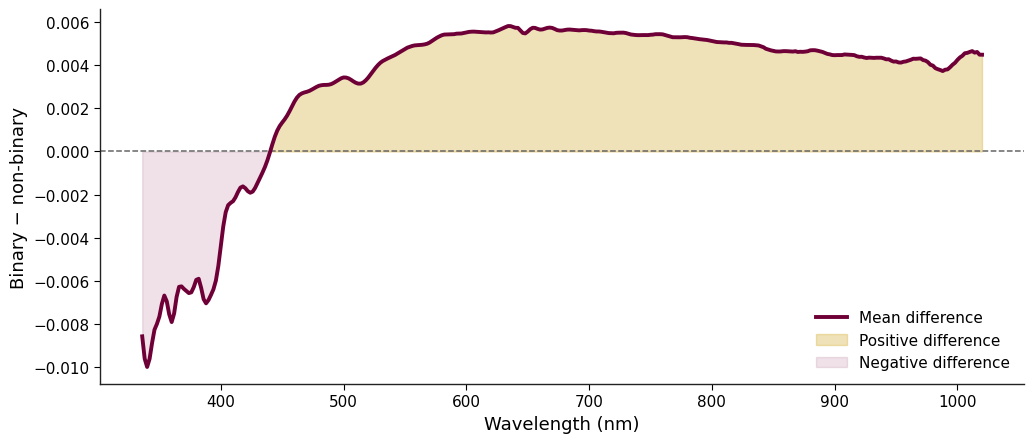

Saved: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\poster_figures\poster_mean_spectral_difference_20260417_1347.png


In [15]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))

ax.plot(
    wavelengths,
    diff_10,
    color=POSTER_RED,
    linewidth=2.8,
    label="Mean difference",
    zorder=3
)

ax.fill_between(
    wavelengths,
    diff_10,
    0,
    where=(diff_10 >= 0),
    color=POSTER_GOLD,
    alpha=0.28,
    interpolate=True,
    label="Positive difference",
    zorder=1
)

ax.fill_between(
    wavelengths,
    diff_10,
    0,
    where=(diff_10 < 0),
    color=POSTER_RED_LIGHT,
    alpha=0.22,
    interpolate=True,
    label="Negative difference",
    zorder=1
)

ax.axhline(
    0,
    color=POSTER_GRAY,
    linestyle="--",
    linewidth=1.1,
    zorder=2
)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Binary − non-binary")

clean_axes(ax)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()

mean_diff_path = OUT_DIR / f"poster_mean_spectral_difference_{TIMESTAMP}.png"
plt.savefig(mean_diff_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", mean_diff_path)


 ## 2. Discrimination curves of linear functional models

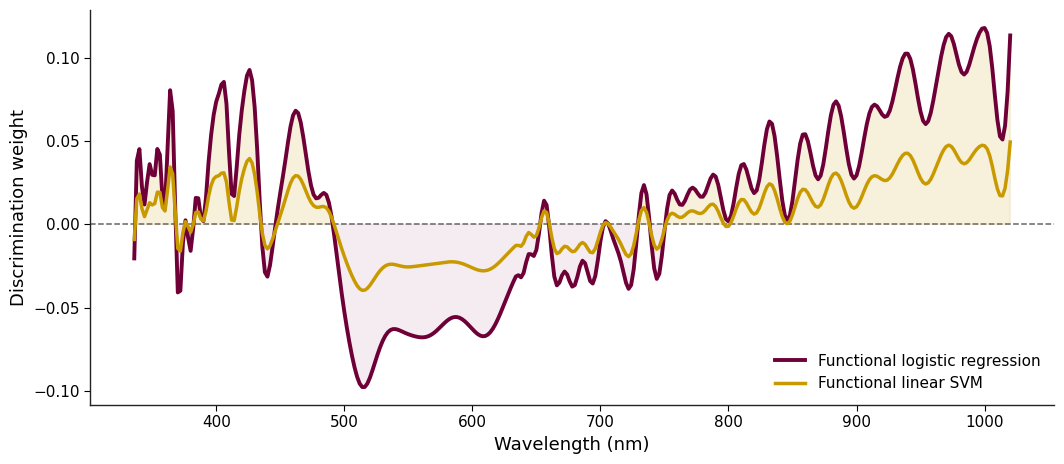

Saved: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\poster_figures\poster_linear_model_discrimination_curves_20260417_1347.png


In [16]:
fig, ax = plt.subplots(figsize=(10.8, 4.8))

# subtle background shading based on logistic regression sign
ax.fill_between(
    wavelengths,
    beta_logreg,
    0,
    where=(beta_logreg >= 0),
    color=POSTER_GOLD,
    alpha=0.14,
    interpolate=True,
    zorder=1
)

ax.fill_between(
    wavelengths,
    beta_logreg,
    0,
    where=(beta_logreg < 0),
    color=POSTER_RED_LIGHT,
    alpha=0.14,
    interpolate=True,
    zorder=1
)

ax.plot(
    wavelengths,
    beta_logreg,
    color=POSTER_RED,
    linewidth=2.8,
    label="Functional logistic regression",
    zorder=3
)

ax.plot(
    wavelengths,
    beta_svm,
    color=POSTER_GOLD,
    linewidth=2.5,
    label="Functional linear SVM",
    zorder=3
)

ax.axhline(
    0,
    color=POSTER_GRAY,
    linestyle="--",
    linewidth=1.1,
    zorder=2
)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Discrimination weight")

clean_axes(ax)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()

compare_path = OUT_DIR / f"poster_linear_model_discrimination_curves_{TIMESTAMP}.png"
plt.savefig(compare_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", compare_path)